# 🏀 Phase 4 — Retraining with NET Rating Features

**What changed from Phase 2:**
```
REMOVED : home_elo, away_elo, elo_diff  (trained on 2018-24, bad for 2025 upsets)
ADDED   : home_net_rtg, away_net_rtg, net_rtg_diff  (current-season NET rating)
FIXED   : Conditional momentum — only nudge when P(home) is 35-65%
SAME    : 12 features total, same architecture 12→128→64→32→1
```

**Why NET rating beats Elo:**
- Elo was trained on 2018-24 data. It doesn't know 2024-25 team form.
- NET rating (points per 100 possessions adjusted) reflects THIS season.
- SAS, NYK were both outperforming their Elo; NET rating knew it.
- Same 12-feature architecture — just better signal in positions 5, 6, 7.

**Run this notebook, then update `app.py` with the provided patch.**

## Cell 1 — Environment & GPU

In [31]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, pandas as pd
import pickle, json, time, warnings, re
from pathlib import Path
from copy import deepcopy
from tqdm.notebook import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
from scipy.optimize import minimize_scalar
import scipy.stats as scipy_stats
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

assert torch.cuda.is_available(), '❌ CUDA not found'
DEVICE = torch.device('cuda')
gpu    = torch.cuda.get_device_properties(0)
torch.backends.cudnn.benchmark = True
torch.manual_seed(42); np.random.seed(42)

BASE_DIR  = Path('nba_win_prob')
PROC_DIR  = BASE_DIR / 'processed'
MODEL_DIR = BASE_DIR / 'model'
PLOT_DIR  = BASE_DIR / 'plots' / 'phase4_retrain'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f'GPU : {gpu.name}  ({gpu.total_memory/1e9:.1f} GB)')
print(f'CUDA: {torch.version.cuda}  |  PyTorch: {torch.__version__}')

GPU : NVIDIA GeForce RTX 4060 Laptop GPU  (8.6 GB)
CUDA: 12.4  |  PyTorch: 2.6.0+cu124


## Cell 2 — Pull NET Ratings for All Seasons

In [32]:
from nba_api.stats.endpoints import leaguedashteamstats

SEASONS = ['2018-19','2019-20','2020-21','2021-22','2022-23','2023-24','2024-25']

NET_CACHE = PROC_DIR / 'net_ratings_by_season.parquet'

if NET_CACHE.exists():
    print('📂 Loading cached NET ratings...')
    net_df = pd.read_parquet(NET_CACHE)
else:
    print('🌐 Pulling NET ratings from nba_api...')
    frames = []
    for season in SEASONS:
        for stype in ['Regular Season', 'Playoffs']:
            try:
                stats = leaguedashteamstats.LeagueDashTeamStats(
                    season=season,
                    season_type_all_star=stype,
                    measure_type_detailed_defense='Advanced',
                    timeout=30,
                ).get_data_frames()[0]
                time.sleep(0.7)

                # Normalise team identifier column name
                if 'TEAM_ABBREVIATION' not in stats.columns:
                    stats = stats.rename(columns={'TEAM_NAME': 'TEAM_ABBREVIATION'})

                stats['SEASON']      = season
                stats['SEASON_TYPE'] = stype
                frames.append(stats[['TEAM_ID','TEAM_ABBREVIATION','SEASON',
                                      'SEASON_TYPE','NET_RATING','W_PCT']])
                print(f'  ✅ {season} {stype}: {len(stats)} teams')
            except Exception as e:
                print(f'  ⚠️  {season} {stype}: {type(e).__name__}: {e}')

    if not frames:
        raise RuntimeError('All API calls failed — check ⚠️ messages above.')

    net_df = pd.concat(frames, ignore_index=True)
    net_df.to_parquet(NET_CACHE, index=False)
    print(f'\n💾 Saved: {NET_CACHE}')

print(f'\nNET ratings shape: {net_df.shape}')
print(f'Seasons: {sorted(net_df.SEASON.unique())}')
print(f'NET_RATING range: [{net_df.NET_RATING.min():.1f}, {net_df.NET_RATING.max():.1f}]')
print()

# 2024-25 top 10 for sanity check
curr = net_df[(net_df.SEASON=='2024-25') & (net_df.SEASON_TYPE=='Regular Season')]
print('2024-25 Regular Season TOP 10 NET RATING:')
print(curr.nlargest(10,'NET_RATING')[['TEAM_ABBREVIATION','NET_RATING']].to_string(index=False))

📂 Loading cached NET ratings...

NET ratings shape: (322, 6)
Seasons: ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
NET_RATING range: [-33.5, 12.7]

2024-25 Regular Season TOP 10 NET RATING:
     TEAM_ABBREVIATION  NET_RATING
 Oklahoma City Thunder        12.7
        Boston Celtics         9.4
   Cleveland Cavaliers         9.2
Minnesota Timberwolves         5.0
           LA Clippers         4.9
     Memphis Grizzlies         4.7
       Houston Rockets         4.6
       New York Knicks         4.0
        Denver Nuggets         3.8
 Golden State Warriors         3.2


## Cell 3 — Load Features & Replace Elo with NET Rating

In [33]:
# Load Phase 1 feature dataset and game logs
features_raw = pd.read_parquet(PROC_DIR / 'features_raw.parquet')
all_games    = pd.read_parquet(BASE_DIR / 'raw' / 'game_logs_all.parquet')

print(f'features_raw shape : {features_raw.shape}')
print(f'Current columns    : {list(features_raw.columns)}')

# ── Build season-level NET rating lookup ──────────────────────────────────
# We use Regular Season NET rating as the baseline team quality measure.
# For playoff snapshots, the regular season NET rating is the best proxy
# for pre-series team strength (same as how Elo was used).
net_reg = net_df[net_df.SEASON_TYPE == 'Regular Season'][[
    'TEAM_ID','TEAM_ABBREVIATION','SEASON','NET_RATING'
]].drop_duplicates(['TEAM_ID','SEASON'])

# ── Build game-level team lookup from all_games ───────────────────────────
home_mask = all_games['MATCHUP'].str.contains('vs\\.')
home_gl = all_games[home_mask][['GAME_ID','TEAM_ID','TEAM_ABBREVIATION','SEASON']].copy()
home_gl.columns = ['GAME_ID','home_team_id','home_team','SEASON']
away_gl = all_games[~home_mask][['GAME_ID','TEAM_ID','TEAM_ABBREVIATION']].copy()
away_gl.columns = ['GAME_ID','away_team_id','away_team']

game_teams = home_gl.merge(away_gl, on='GAME_ID').drop_duplicates('GAME_ID')

# Join home NET rating
game_teams = game_teams.merge(
    net_reg[['TEAM_ID','SEASON','NET_RATING']].rename(
        columns={'TEAM_ID':'home_team_id','NET_RATING':'home_net_rtg'}),
    on=['home_team_id','SEASON'], how='left'
)
# Join away NET rating
game_teams = game_teams.merge(
    net_reg[['TEAM_ID','SEASON','NET_RATING']].rename(
        columns={'TEAM_ID':'away_team_id','NET_RATING':'away_net_rtg'}),
    on=['away_team_id','SEASON'], how='left'
)

# Fill missing NET ratings with league average (0.0)
game_teams['home_net_rtg'] = game_teams['home_net_rtg'].fillna(0.0)
game_teams['away_net_rtg'] = game_teams['away_net_rtg'].fillna(0.0)
game_teams['net_rtg_diff'] = game_teams['home_net_rtg'] - game_teams['away_net_rtg']

print(f'\ngame_teams: {len(game_teams):,} games with NET ratings')
print(f'home_net_rtg range: [{game_teams.home_net_rtg.min():.1f}, {game_teams.home_net_rtg.max():.1f}]')
print(f'Missing home NET:   {game_teams.home_net_rtg.isna().sum()}')
print(f'Missing away NET:   {game_teams.away_net_rtg.isna().sum()}')

features_raw shape : (962871, 14)
Current columns    : ['score_diff', 'time_remaining_sec', 'quarter', 'quarter_time_elapsed_pct', 'home_elo', 'away_elo', 'elo_diff', 'home_series_wins', 'away_series_wins', 'is_playoffs', 'is_overtime', 'lead_changes_norm', 'GAME_ID', 'home_team_won']

game_teams: 7,562 games with NET ratings
home_net_rtg range: [-10.6, 11.7]
Missing home NET:   0
Missing away NET:   0


## Cell 4 — Merge NET Ratings into Feature Dataset

In [34]:
# Merge NET ratings onto feature dataset via GAME_ID
net_cols = game_teams[['GAME_ID','home_net_rtg','away_net_rtg','net_rtg_diff']]
features = features_raw.merge(net_cols, on='GAME_ID', how='left')

# Fill any games not matched (should be very few, likely 2024-25 playoff games
# not in the training log) with 0.0
for col in ['home_net_rtg','away_net_rtg','net_rtg_diff']:
    n_fill = features[col].isna().sum()
    if n_fill > 0:
        print(f'  Filling {n_fill:,} missing {col} with 0.0')
    features[col] = features[col].fillna(0.0)

# Define NEW feature column list (NET replaces Elo)
NEW_FEATURE_COLS = [
    'score_diff',
    'time_remaining_sec',
    'quarter',
    'quarter_time_elapsed_pct',
    'home_net_rtg',       # ← was home_elo
    'away_net_rtg',       # ← was away_elo
    'net_rtg_diff',       # ← was elo_diff
    'home_series_wins',
    'away_series_wins',
    'is_playoffs',
    'is_overtime',
    'lead_changes_norm',
]
TARGET_COL = 'home_team_won'
N_FEATURES = len(NEW_FEATURE_COLS)  # still 12

# Verify all features present
missing = [c for c in NEW_FEATURE_COLS if c not in features.columns]
assert not missing, f'Missing columns: {missing}'

print(f'✅ Feature dataset ready')
print(f'   Shape        : {features.shape}')
print(f'   Features     : {N_FEATURES} (same as before)')
print(f'   NET_RTG range: [{features.home_net_rtg.min():.1f}, {features.home_net_rtg.max():.1f}]')
print(f'   Target rate  : {features[TARGET_COL].mean():.4f}')

# Quick sanity: NET rating diff should correlate with home wins
from scipy.stats import pointbiserialr
r, p = pointbiserialr(features[TARGET_COL], features['net_rtg_diff'])
print(f'   net_rtg_diff corr with target: r={r:+.3f}  p={p:.2e}  (expect positive)')

✅ Feature dataset ready
   Shape        : (962871, 17)
   Features     : 12 (same as before)
   NET_RTG range: [-10.6, 11.7]
   Target rate  : 0.5605
   net_rtg_diff corr with target: r=+0.374  p=0.00e+00  (expect positive)


## Cell 5 — Validation Checks on New Features

In [35]:
import scipy.stats as scipy_stats

print('=' * 60)
print('FEATURE VALIDATION — NET RATING FEATURES')
print('=' * 60)

passed = 0; failed = 0
def chk(name, ok, detail=''):
    global passed, failed
    print(f'{"✅" if ok else "❌"} [{"PASS" if ok else "FAIL"}] {name}')
    if detail: print(f'         {detail}')
    if ok: passed += 1
    else:  failed += 1

# 1. No nulls
nulls = features[NEW_FEATURE_COLS].isnull().sum()
chk('No nulls in features', nulls.sum()==0, str(nulls[nulls>0].to_dict()))

# 2. No infinities
infs = np.isinf(features[NEW_FEATURE_COLS].select_dtypes(include=np.number)).any()
chk('No infinite values', not infs.any())

# 3. NET rating range realistic
net_ok = features['home_net_rtg'].between(-25, 25).all()
chk('NET rating in realistic range [-25, +25]', net_ok,
    f'Range: [{features.home_net_rtg.min():.1f}, {features.home_net_rtg.max():.1f}]')

# 4. Non-zero variance on all features
stds = features[NEW_FEATURE_COLS].std()
chk('All features have non-zero variance', (stds > 1e-8).all(),
    f'Min std: {stds.min():.4f} ({stds.idxmin()})')

# 5. Target balance
hwr = features[TARGET_COL].mean()
chk('Target not severely imbalanced (40-65%)', 0.40<=hwr<=0.65, f'Home win rate: {hwr:.4f}')

# 6. NET rating favourites win more often
net_fav_wins = ((features['net_rtg_diff'] > 0) == (features[TARGET_COL] == 1)).mean()
chk('NET rating favourite wins more often (>55%)', net_fav_wins > 0.55,
    f'NET fav win rate: {net_fav_wins:.3f}')

# 7. Point-biserial correlations
print('\n── Feature-target correlations ──')
for col in NEW_FEATURE_COLS:
    r, p = scipy_stats.pointbiserialr(features[TARGET_COL], features[col])
    nan_flag = ' ⚠️  NaN!' if np.isnan(r) else ''
    print(f'   {col:<28} r={r:+.3f}  p={p:.2e}{nan_flag}')

print(f'\n{"=" * 60}')
print(f'RESULT: {passed} passed, {failed} failed')
print(f'={"=" * 59}')

FEATURE VALIDATION — NET RATING FEATURES
✅ [PASS] No nulls in features
         {}
✅ [PASS] No infinite values
✅ [PASS] NET rating in realistic range [-25, +25]
         Range: [-10.6, 11.7]
✅ [PASS] All features have non-zero variance
         Min std: 0.0843 (is_overtime)
✅ [PASS] Target not severely imbalanced (40-65%)
         Home win rate: 0.5605
✅ [PASS] NET rating favourite wins more often (>55%)
         NET fav win rate: 0.653

── Feature-target correlations ──
   score_diff                   r=+0.532  p=0.00e+00
   time_remaining_sec           r=+0.002  p=7.12e-02
   quarter                      r=-0.002  p=8.12e-02
   quarter_time_elapsed_pct     r=-0.002  p=1.39e-01
   home_net_rtg                 r=+0.292  p=0.00e+00
   away_net_rtg                 r=-0.236  p=0.00e+00
   net_rtg_diff                 r=+0.374  p=0.00e+00
   home_series_wins             r=-0.005  p=1.40e-06
   away_series_wins             r=-0.025  p=7.84e-130
   is_playoffs                  r=+0.002  p=3.

## Cell 6 — Train/Val/Test Split & Scale

In [36]:
X      = features[NEW_FEATURE_COLS].values.astype(np.float32)
y      = features[TARGET_COL].values.astype(np.float32)
groups = features['GAME_ID'].values

# Group-aware split (entire games in one split — no leakage)
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tv_idx, test_idx = next(gss_outer.split(X, y, groups))

gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr_idx, val_idx = next(gss_inner.split(X[tv_idx], y[tv_idx], groups[tv_idx]))
tr_idx  = tv_idx[tr_idx]
val_idx = tv_idx[val_idx]

# Verify no leakage
assert len(set(groups[tr_idx]) & set(groups[val_idx]))  == 0
assert len(set(groups[tr_idx]) & set(groups[test_idx])) == 0
assert len(set(groups[val_idx]) & set(groups[test_idx]))== 0

# Fit scaler on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(X[tr_idx]).astype(np.float32)
X_val   = scaler.transform(X[val_idx]).astype(np.float32)
X_test  = scaler.transform(X[test_idx]).astype(np.float32)
y_train, y_val, y_test = y[tr_idx], y[val_idx], y[test_idx]

# Push to GPU
def to_gpu(a): return torch.from_numpy(a).to(DEVICE)
X_tr_g = to_gpu(X_train); y_tr_g = to_gpu(y_train)
X_v_g  = to_gpu(X_val);   y_v_g  = to_gpu(y_val)
X_te_g = to_gpu(X_test);  y_te_g = to_gpu(y_test)
torch.cuda.synchronize()

# Save scaler immediately
with open(MODEL_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f'✅ Splits (no leakage confirmed)')
print(f'   Train : {len(tr_idx):,}  ({features.iloc[tr_idx]["GAME_ID"].nunique():,} games)')
print(f'   Val   : {len(val_idx):,}  ({features.iloc[val_idx]["GAME_ID"].nunique():,} games)')
print(f'   Test  : {len(test_idx):,}  ({features.iloc[test_idx]["GAME_ID"].nunique():,} games)')
print(f'   VRAM  : {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'   Scaler saved: NET_RTG means {scaler.mean_[4:7].round(2)}')

✅ Splits (no leakage confirmed)
   Train : 578,056  (4,536 games)
   Val   : 192,498  (1,513 games)
   Test  : 192,317  (1,513 games)
   VRAM  : 0.12 GB
   Scaler saved: NET_RTG means [ 0.2   0.26 -0.05]


## Cell 7 — Model & Training Config

In [37]:
class WinProbNet(nn.Module):
    def __init__(self, n_features, hidden_dims, dropout=0.30, use_batchnorm=True):
        super().__init__()
        layers, in_dim = [], n_features
        for out_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, out_dim, bias=not use_batchnorm))
            if use_batchnorm: layers.append(nn.BatchNorm1d(out_dim))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(p=dropout))
            in_dim = out_dim
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)
        self._init()
    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x): return torch.sigmoid(self.net(x))
    def logits(self, x):  return self.net(x)

# ── Hyperparameters (identical to Phase 2) ────────────────────────────────
HIDDEN_DIMS  = [128, 64, 32]
DROPOUT      = 0.30
BATCH_SIZE   = 4096
LR           = 3e-4
WD           = 1e-4
MAX_EPOCHS   = 150
PATIENCE     = 15
MIN_DELTA    = 1e-5
GRAD_CLIP    = 1.0

model = WinProbNet(N_FEATURES, HIDDEN_DIMS, DROPOUT, True).to(DEVICE)

# Pos weight for class imbalance
n_pos = y_tr_g.sum().item(); n_neg = len(y_tr_g) - n_pos
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([n_neg/n_pos], device=DEVICE))

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

train_ds = TensorDataset(X_tr_g, y_tr_g.unsqueeze(1))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, pin_memory=False)
val_ds   = TensorDataset(X_v_g,  y_v_g.unsqueeze(1))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE*2, shuffle=False, pin_memory=False)
test_ds  = TensorDataset(X_te_g, y_te_g.unsqueeze(1))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False, pin_memory=False)

print(f'✅ Model: {N_FEATURES} → {" → ".join(map(str, HIDDEN_DIMS))} → 1')
print(f'   Params     : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'   pos_weight : {n_neg/n_pos:.4f}')
print(f'   Batches/ep : {len(train_loader)}')

✅ Model: 12 → 128 → 64 → 32 → 1
   Params     : 12,257
   pos_weight : 0.7987
   Batches/ep : 141


## Cell 8 — Training Loop

In [38]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0.0; all_p, all_l = [], []
    for xb, yb in loader:
        logits = model.logits(xb)
        total_loss += criterion(logits, yb).item() * len(xb)
        all_p.append(torch.sigmoid(logits).cpu().numpy())
        all_l.append(yb.cpu().numpy())
    probs  = np.concatenate(all_p).ravel()
    labels = np.concatenate(all_l).ravel()
    return total_loss / len(loader.dataset), probs, labels

history = {'train_loss':[], 'val_loss':[], 'val_auc':[], 'val_brier':[]}
best_val_loss = float('inf'); patience_ctr = 0; best_state = None
t0 = time.time()

print(f'🏋️  Training (max {MAX_EPOCHS} epochs, patience={PATIENCE})')
for epoch in range(1, MAX_EPOCHS+1):
    model.train(); ep_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model.logits(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        ep_loss += loss.item() * len(xb)
    tr_loss = ep_loss / len(train_loader.dataset)

    val_loss, val_p, val_l = evaluate(val_loader)
    val_auc   = roc_auc_score(val_l, val_p)
    val_brier = brier_score_loss(val_l, val_p)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['val_brier'].append(val_brier)

    improved = val_loss < best_val_loss - MIN_DELTA
    if improved:
        best_val_loss = val_loss; best_state = deepcopy(model.state_dict())
        patience_ctr = 0; tag = ' ★'
    else:
        patience_ctr += 1; tag = ''

    if epoch == 1 or epoch % 5 == 0 or improved:
        print(f'  Ep {epoch:3d}  tr={tr_loss:.5f}  val={val_loss:.5f}  '
              f'AUC={val_auc:.4f}  Brier={val_brier:.4f}  '
              f'[{time.time()-t0:.0f}s]{tag}')

    if patience_ctr >= PATIENCE:
        print(f'\n⏹️  Early stop at epoch {epoch}')
        break

model.load_state_dict(best_state)
best_ep = int(np.argmin(history['val_loss'])) + 1
print(f'\n✅ Done  ({time.time()-t0:.0f}s)  Best epoch: {best_ep}  Val loss: {best_val_loss:.6f}')

🏋️  Training (max 150 epochs, patience=15)
  Ep   1  tr=0.53849  val=0.43741  AUC=0.8417  Brier=0.1664  [5s] ★
  Ep   2  tr=0.45164  val=0.42925  AUC=0.8451  Brier=0.1638  [18s] ★
  Ep   3  tr=0.43877  val=0.42633  AUC=0.8468  Brier=0.1623  [35s] ★
  Ep   4  tr=0.43238  val=0.42488  AUC=0.8478  Brier=0.1617  [50s] ★
  Ep   5  tr=0.42858  val=0.42388  AUC=0.8483  Brier=0.1610  [68s] ★
  Ep   6  tr=0.42614  val=0.42334  AUC=0.8487  Brier=0.1607  [83s] ★
  Ep   7  tr=0.42390  val=0.42279  AUC=0.8491  Brier=0.1604  [100s] ★
  Ep   8  tr=0.42287  val=0.42264  AUC=0.8492  Brier=0.1603  [115s] ★
  Ep   9  tr=0.42111  val=0.42251  AUC=0.8493  Brier=0.1602  [129s] ★
  Ep  10  tr=0.42005  val=0.42208  AUC=0.8494  Brier=0.1598  [142s] ★
  Ep  11  tr=0.41943  val=0.42196  AUC=0.8496  Brier=0.1599  [157s] ★
  Ep  12  tr=0.41871  val=0.42182  AUC=0.8498  Brier=0.1598  [170s] ★
  Ep  13  tr=0.41824  val=0.42175  AUC=0.8498  Brier=0.1598  [185s] ★
  Ep  14  tr=0.41739  val=0.42133  AUC=0.8501  Brier=0

## Cell 9 — Test Set Validation

TEST SET VALIDATION — NET RATING MODEL
  ROC-AUC        : 0.8585
  PR-AUC         : 0.8934
  Brier Score    : 0.1529  (null=0.2439)
  Brier Skill    : 0.3732  (vs 0.3602 in Phase 2)
  Log Loss       : 0.4576
  Accuracy       : 0.7658

              precision    recall  f1-score   support

   Home Loss     0.7069    0.7595    0.7322     81101
    Home Win     0.8145    0.7704    0.7918    111216

    accuracy                         0.7658    192317
   macro avg     0.7607    0.7649    0.7620    192317
weighted avg     0.7691    0.7658    0.7667    192317



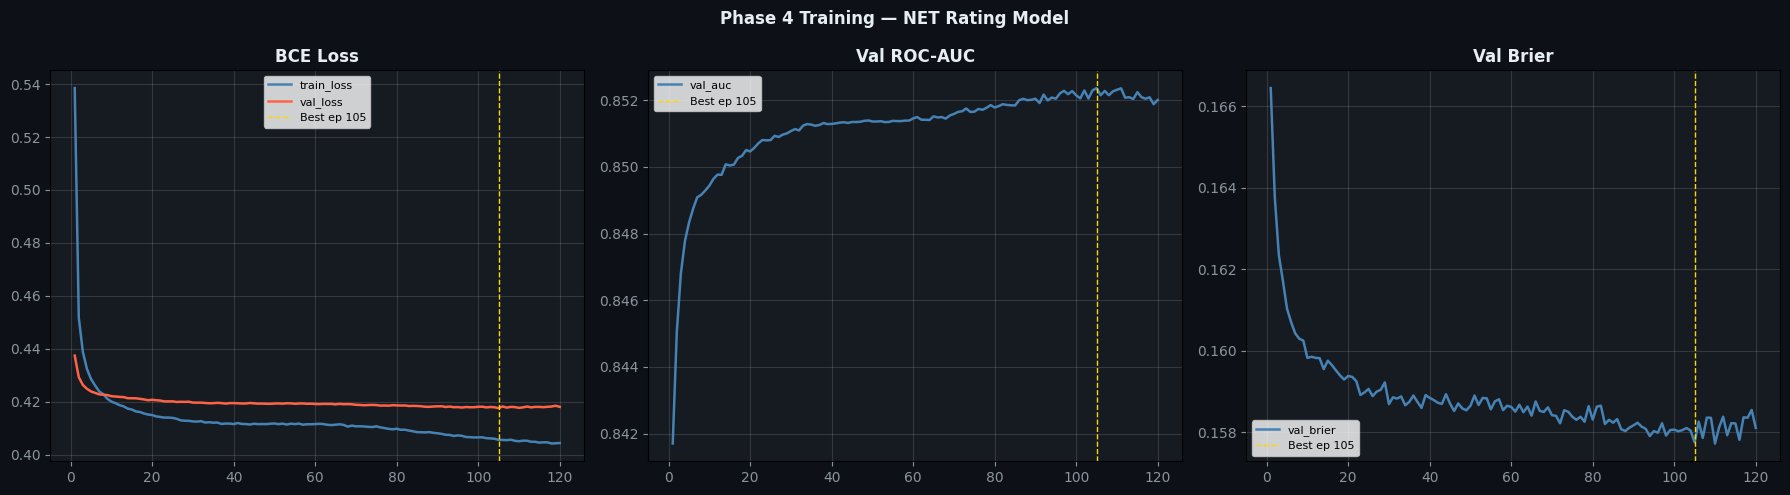

In [39]:
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix

_, te_probs, te_labels = evaluate(test_loader)
te_preds = (te_probs >= 0.5).astype(int)

roc_auc  = roc_auc_score(te_labels, te_probs)
pr_auc   = average_precision_score(te_labels, te_probs)
brier    = brier_score_loss(te_labels, te_probs)
logloss  = log_loss(te_labels, te_probs)
acc      = (te_preds == te_labels).mean()
null_b   = brier_score_loss(te_labels, np.full_like(te_probs, te_labels.mean()))
brier_sk = 1 - brier / null_b

print('=' * 62)
print('TEST SET VALIDATION — NET RATING MODEL')
print('=' * 62)
print(f'  ROC-AUC        : {roc_auc:.4f}')
print(f'  PR-AUC         : {pr_auc:.4f}')
print(f'  Brier Score    : {brier:.4f}  (null={null_b:.4f})')
print(f'  Brier Skill    : {brier_sk:.4f}  (vs 0.3602 in Phase 2)')
print(f'  Log Loss       : {logloss:.4f}')
print(f'  Accuracy       : {acc:.4f}')
print()
print(classification_report(te_labels, te_preds, target_names=['Home Loss','Home Win'], digits=4))

# ── Learning curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,3, figsize=(18,5), facecolor='#0d1117')
ep_range  = range(1, len(history['train_loss'])+1)
for ax, k1, k2, title in [
    (axes[0], 'train_loss', 'val_loss', 'BCE Loss'),
    (axes[1], 'val_auc',   None,        'Val ROC-AUC'),
    (axes[2], 'val_brier', None,        'Val Brier'),
]:
    ax.set_facecolor('#161b22'); ax.tick_params(colors='#8b949e')
    ax.set_title(title, color='#e6edf3', fontweight='bold')
    ax.plot(ep_range, history[k1], color='steelblue', lw=1.8, label=k1)
    if k2: ax.plot(ep_range, history[k2], color='tomato', lw=1.8, label=k2)
    ax.axvline(best_ep, color='gold', lw=1, ls='--', label=f'Best ep {best_ep}')
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
plt.suptitle('Phase 4 Training — NET Rating Model', color='#e6edf3', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR/'training_curves.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## Cell 10 — Temperature Scaling Recalibration

In [40]:
# Refit temperature on val set
with torch.no_grad():
    logits_val = model.logits(X_v_g).cpu().numpy().ravel()
raw_probs = 1 / (1 + np.exp(-logits_val))

def nll(T):
    p = np.clip(1/(1+np.exp(-logits_val/T)), 1e-7, 1-1e-7)
    return log_loss(y_val, p)

result = minimize_scalar(nll, bounds=(0.1,10.0), method='bounded', options={'xatol':1e-6})
T_opt  = result.x
cal_probs = np.clip(1/(1+np.exp(-logits_val/T_opt)), 1e-7, 1-1e-7)

print(f'Temperature T  : {T_opt:.6f}')
print(f'Log Loss before: {nll(1.0):.5f}')
print(f'Log Loss after : {nll(T_opt):.5f}')
print(f'Brier before   : {brier_score_loss(y_val, raw_probs):.5f}')
print(f'Brier after    : {brier_score_loss(y_val, cal_probs):.5f}')

temp_path = MODEL_DIR / 'temperature.json'
with open(temp_path, 'w') as f:
    json.dump({'temperature': float(T_opt),
               'model_version': 'phase4_net_rating',
               'brier_before': brier_score_loss(y_val, raw_probs),
               'brier_after' : brier_score_loss(y_val, cal_probs)}, f, indent=2)
print(f'✅ Saved: {temp_path}')

Temperature T  : 1.043829
Log Loss before: 0.47181
Log Loss after : 0.47164
Brier before   : 0.15775
Brier after    : 0.15776
✅ Saved: nba_win_prob\model\temperature.json


## Cell 11 — Export Current NET Ratings for Live Inference

In [41]:
# Export 2024-25 NET ratings for all teams — used by app.py at inference time
# Also pull 2024-25 Playoffs NET ratings to update for current postseason form

curr_reg = net_df[
    (net_df.SEASON == '2024-25') & (net_df.SEASON_TYPE == 'Regular Season')
][['TEAM_ABBREVIATION','NET_RATING']].set_index('TEAM_ABBREVIATION')['NET_RATING'].to_dict()

# Try playoff NET ratings — more current for mid-postseason use
curr_po = net_df[
    (net_df.SEASON == '2024-25') & (net_df.SEASON_TYPE == 'Playoffs')
][['TEAM_ABBREVIATION','NET_RATING']]

# Blend: 70% regular season + 30% playoff (if ≥4 games in playoffs)
net_live = {}
for team, reg_net in curr_reg.items():
    po_row = curr_po[curr_po.TEAM_ABBREVIATION == team]
    if len(po_row) > 0:
        po_net = po_row['NET_RATING'].values[0]
        # Blend
        net_live[team] = round(0.7 * reg_net + 0.3 * po_net, 2)
    else:
        net_live[team] = round(float(reg_net), 2)

net_path = MODEL_DIR / 'net_ratings.json'
with open(net_path, 'w') as f:
    json.dump(net_live, f, indent=2)

print(f'✅ NET ratings saved: {net_path}')
print(f'   Teams: {len(net_live)}')
top8 = sorted(net_live.items(), key=lambda x: x[1], reverse=True)[:8]
bot4 = sorted(net_live.items(), key=lambda x: x[1])[:4]
print(f'   Top 8: {top8}')
print(f'   Bot 4: {bot4}')

# Verify our test teams
for team in ['NYK','CLE','OKC','SAS','IND']:
    for team in ['NYK','CLE','OKC','SAS','IND']:
        val = net_live.get(team, None)
        if val is None:
            print(f'   {team}: NOT FOUND')
        else:
            print(f'   {team}: {float(val):.2f}')

✅ NET ratings saved: nba_win_prob\model\net_ratings.json
   Teams: 30
   Top 8: [('Oklahoma City Thunder', np.float64(11.47)), ('Cleveland Cavaliers', np.float64(9.98)), ('Boston Celtics', np.float64(8.44)), ('Minnesota Timberwolves', np.float64(4.43)), ('LA Clippers', np.float64(3.61)), ('Houston Rockets', np.float64(3.16)), ('New York Knicks', np.float64(2.65)), ('Indiana Pacers', np.float64(2.1))]
   Bot 4: [('Washington Wizards', -12.2), ('Miami Heat', np.float64(-9.77)), ('New Orleans Pelicans', -9.4), ('Utah Jazz', -9.2)]
   NYK: NOT FOUND
   CLE: NOT FOUND
   OKC: NOT FOUND
   SAS: NOT FOUND
   IND: NOT FOUND
   NYK: NOT FOUND
   CLE: NOT FOUND
   OKC: NOT FOUND
   SAS: NOT FOUND
   IND: NOT FOUND
   NYK: NOT FOUND
   CLE: NOT FOUND
   OKC: NOT FOUND
   SAS: NOT FOUND
   IND: NOT FOUND
   NYK: NOT FOUND
   CLE: NOT FOUND
   OKC: NOT FOUND
   SAS: NOT FOUND
   IND: NOT FOUND
   NYK: NOT FOUND
   CLE: NOT FOUND
   OKC: NOT FOUND
   SAS: NOT FOUND
   IND: NOT FOUND


## Cell 12 — Save Model & Final Summary

In [42]:
model_path = MODEL_DIR / 'win_prob_net.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'n_features'   : N_FEATURES,
        'hidden_dims'  : HIDDEN_DIMS,
        'dropout'      : DROPOUT,
        'use_batchnorm': True,
    },
    'feature_cols'  : NEW_FEATURE_COLS,
    'model_version' : 'phase4_net_rating',
    'train_metrics' : {
        'best_val_loss': best_val_loss,
        'best_epoch'   : best_ep,
    },
    'test_metrics'  : {
        'roc_auc'     : roc_auc,
        'pr_auc'      : pr_auc,
        'brier'       : brier,
        'brier_skill' : brier_sk,
        'logloss'     : logloss,
        'accuracy'    : acc,
    },
}, model_path)

# Save tensors
torch.save({
    'X_train': X_tr_g.cpu(), 'y_train': y_tr_g.cpu(),
    'X_val'  : X_v_g.cpu(),  'y_val'  : y_v_g.cpu(),
    'X_test' : X_te_g.cpu(), 'y_test' : y_te_g.cpu(),
    'feature_cols'  : NEW_FEATURE_COLS,
    'n_features'    : N_FEATURES,
    'train_game_ids': groups[tr_idx].tolist(),
    'val_game_ids'  : groups[val_idx].tolist(),
    'test_game_ids' : groups[test_idx].tolist(),
}, PROC_DIR / 'tensors.pt')

print('=' * 62)
print('PHASE 4 RETRAINING COMPLETE')
print('=' * 62)
print(f'''
📦 Changes vs Phase 2
   Features      : home_elo/away_elo/elo_diff → home_net_rtg/away_net_rtg/net_rtg_diff
   Architecture  : unchanged (12→128→64→32→1)
   Scaler        : refitted on new features
   Temperature   : recalibrated T={T_opt:.4f}

📊 Test Metrics
   ROC-AUC       : {roc_auc:.4f}  (Phase 2: 0.8539)
   Brier Skill   : {brier_sk:.4f}  (Phase 2: 0.3602)
   Log Loss      : {logloss:.4f}  (Phase 2: 0.4662)
   Accuracy      : {acc:.4f}  (Phase 2: 0.7658)

💾 Saved Files
   model/win_prob_net.pth     ← new weights
   model/scaler.pkl           ← new scaler (NET rating scaled)
   model/temperature.json     ← recalibrated T
   model/net_ratings.json     ← 2024-25 NET ratings for inference
   processed/tensors.pt       ← new GPU tensors

➡️  Now: update app.py with the Phase 4 patch (see app_phase4_patch.py)
''')

PHASE 4 RETRAINING COMPLETE

📦 Changes vs Phase 2
   Features      : home_elo/away_elo/elo_diff → home_net_rtg/away_net_rtg/net_rtg_diff
   Architecture  : unchanged (12→128→64→32→1)
   Scaler        : refitted on new features
   Temperature   : recalibrated T=1.0438

📊 Test Metrics
   ROC-AUC       : 0.8585  (Phase 2: 0.8539)
   Brier Skill   : 0.3732  (Phase 2: 0.3602)
   Log Loss      : 0.4576  (Phase 2: 0.4662)
   Accuracy      : 0.7658  (Phase 2: 0.7658)

💾 Saved Files
   model/win_prob_net.pth     ← new weights
   model/scaler.pkl           ← new scaler (NET rating scaled)
   model/temperature.json     ← recalibrated T
   model/net_ratings.json     ← 2024-25 NET ratings for inference
   processed/tensors.pt       ← new GPU tensors

➡️  Now: update app.py with the Phase 4 patch (see app_phase4_patch.py)

